In [25]:
# ============================================
# STEP 2: LOAD THE DATASET
# ============================================

print("\n" + "="*70)
print(" STEP 2: LOADING DATASET")
print("="*70)

try:
    df = pd.read_csv('dataset.csv')
    print("\n✓ Dataset loaded successfully from 'dataset.csv'")
except FileNotFoundError:
    print("\n✗ File 'dataset.csv' not found!")
    print("  Please make sure the file is in the same directory")
    exit()

print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] - 1}")

print("\nFirst 5 rows:")
print(df.head())



 STEP 2: LOADING DATASET

✓ Dataset loaded successfully from 'dataset.csv'

Dataset Shape: 690 rows and 16 columns
Number of samples: 690
Number of features: 15

First 5 rows:
   Gender    Age   Debt  Married  BankCustomer     Industry Ethnicity  \
0       1  30.83  0.000      1.0             1  Industrials     White   
1       0  58.67  4.460      1.0             1    Materials     Black   
2       0   24.5  0.500      1.0             1    Materials     Black   
3       1  27.83  1.540      1.0             1  Industrials     White   
4       1  20.17  5.625      1.0             1  Industrials     White   

   YearsEmployed  PriorDefault  Employed  CreditScore  DriversLicense  \
0           1.25             1       1.0            1               0   
1           3.04             1       1.0            6               0   
2           1.50             1       0.0            0               0   
3           3.75             1       1.0            5               1   
4           1.71   

In [26]:
# ============================================
# STEP 3: UNDERSTAND THE DATA
# ============================================

print("\n" + "="*70)
print(" STEP 3: UNDERSTANDING THE DATA")
print("="*70)

# 3.1 Check data types
print("\n3.1 Data Types:")
print(df.dtypes)

# 3.2 Check missing values
print("\n3.2 Missing Values Before Handling:")
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
if len(missing_before) > 0:
    print(missing_before)
else:
    print("No missing values found")

# 3.3 Target distribution
print("\n3.3 Target Variable Distribution:")
target_counts = df['Approved'].value_counts()
print(f"  Not Approved (0): {target_counts.get(0, 0)} ({target_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"  Approved (1): {target_counts.get(1, 0)} ({target_counts.get(1, 0)/len(df)*100:.1f}%)")



 STEP 3: UNDERSTANDING THE DATA

3.1 Data Types:
Gender              int64
Age                object
Debt              float64
Married           float64
BankCustomer        int64
Industry           object
Ethnicity          object
YearsEmployed     float64
PriorDefault        int64
Employed          float64
CreditScore         int64
DriversLicense      int64
Citizen            object
ZipCode             int64
Income            float64
Approved            int64
dtype: object

3.2 Missing Values Before Handling:
Age          4
Married     10
Employed     8
Income       2
dtype: int64

3.3 Target Variable Distribution:
  Not Approved (0): 383 (55.5%)
  Approved (1): 307 (44.5%)


Text(194.44444444444446, 0.5, 'Rows')

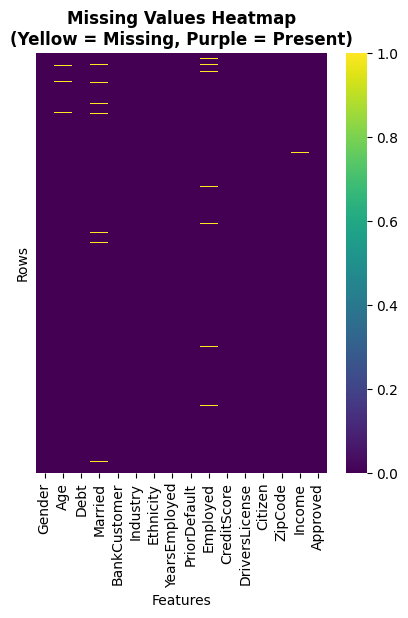

In [27]:
fig = plt.figure(figsize=(16, 12))

# Plot 1: Missing Values Heatmap
ax1 = plt.subplot(2, 3, 1)
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=ax1)
ax1.set_title('Missing Values Heatmap\n(Yellow = Missing, Purple = Present)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Features')
ax1.set_ylabel('Rows')

In [28]:
# ============================================
# STEP 4: HANDLE MISSING VALUES
# ============================================

print("\n" + "="*70)
print(" STEP 4: HANDLING MISSING VALUES")
print("="*70)

# Create a copy for preprocessing
df_clean = df.copy()



#  Age (numeric) - fill with median becouse less sentitive to outiers 
if df_clean['Age'].isnull().sum() > 0:
    age_median = df_clean['Age'].median()
    df_clean['Age'].fillna(age_median, inplace=True)
    print(f"\n✓ Age: Filled {df['Age'].isnull().sum()} missing values with median = {age_median}")





 STEP 4: HANDLING MISSING VALUES


TypeError: Cannot convert ['30.83' '58.67' '24.5' '27.83' '20.17' '32.08' '33.17' '22.92' '54.42'
 '42.5' '22.08' '29.92' '38.25' '48.08' '45.83' '36.67' '28.25' '23.25'
 '21.83' '19.17' nan '23.25' '47.75' '27.42' '41.17' '15.83' '47' '56.58'
 '57.42' '42.08' '29.25' '42' '49.5' '36.75' '22.58' '27.83' '27.25' '23'
 '27.75' '54.58' '34.17' '28.92' '29.67' '39.58' '56.42' '54.33' nan
 '31.92' '41.5' '23.92' '25.75' '26' '37.42' '34.92' '34.25' '23.33'
 '23.17' '44.33' '35.17' '43.25' nan '31.67' '23.42' '20.42' '26.67'
 '34.17' '36' '25.5' '19.42' '35.17' '32.33' '34.83' '38.58' '44.25'
 '44.83' '20.67' '34.08' '19.17' '21.67' '21.5' '49.58' '27.67' '39.83'
 '28.46' '27.25' '37.17' '28.46' '25.67' '34' '49' '62.5' '31.42' '28.46'
 '52.33' '28.75' '28.58' '23' nan '22.5' '28.5' '37.5' '35.25' '18.67'
 '25' '27.83' '54.83' '28.75' '25' '40.92' '19.75' '29.17' '24.5' '24.58'
 '33.75' '20.67' '25.42' '37.75' '52.5' '57.83' '20.75' '39.92' '25.67'
 '24.75' '44.17' '23.5' '34.92' '47.67' '22

In [12]:
    
print("  - Married (categorical 0/1): Fill with MODE (most common value)")
# Handle Married (categorical 0/1) - fill with mode
if df_clean['Married'].isnull().sum() > 0:
    married_mode = df_clean['Married'].mode()[0]
    df_clean['Married'].fillna(married_mode, inplace=True)
    print(f"✓ Married: Filled {df['Married'].isnull().sum()} missing values with mode = {married_mode}")

  - Married (categorical 0/1): Fill with MODE (most common value)
✓ Married: Filled 6 missing values with mode = 1.0


In [13]:
print("  - Employed (categorical 0/1): Fill with MODE")
# Handle Employed (categorical 0/1) - fill with mode
if df_clean['Employed'].isnull().sum() > 0:
    employed_mode = df_clean['Employed'].mode()[0]
    df_clean['Employed'].fillna(employed_mode, inplace=True)
    print(f"✓ Employed: Filled {df['Employed'].isnull().sum()} missing values with mode = {employed_mode}")

  - Employed (categorical 0/1): Fill with MODE
✓ Employed: Filled 4 missing values with mode = 0.0


In [14]:
print("  - Income (numeric): Fill with MEDIAN")
# Handle Income (numeric) - fill with median
if df_clean['Income'].isnull().sum() > 0:
    income_median = df_clean['Income'].median()
    df_clean['Income'].fillna(income_median, inplace=True)
    print(f"✓ Income: Filled {df['Income'].isnull().sum()} missing values with median = {income_median}")

# Verify no missing values remain
print("\n4.2 Verifying missing values after handling:")
remaining_missing = df_clean.isnull().sum().sum()
if remaining_missing == 0:
    print("  ✓ No missing values remain!")
else:
    print(f"  ⚠ Still have {remaining_missing} missing values")

  - Income (numeric): Fill with MEDIAN
✓ Income: Filled 2 missing values with median = 5.0

4.2 Verifying missing values after handling:
  ✓ No missing values remain!


In [15]:
# ============================================
# STEP 5: FEATURE ENGINEERING
# ============================================

print("\n" + "="*70)
print(" STEP 5: FEATURE ENGINEERING")
print("="*70)

# Separate features and target
X = df_clean.drop('Approved', axis=1)
y = df_clean['Approved']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n5.1 Column Classification:")
print(f"  Numeric columns ({len(numeric_cols)}): {numeric_cols[:5]}...")
print(f"  Categorical columns ({len(categorical_cols)}): {categorical_cols}")


 STEP 5: FEATURE ENGINEERING

Features shape: (690, 15)
Target shape: (690,)

5.1 Column Classification:
  Numeric columns (12): ['Gender', 'Age', 'Debt', 'Married', 'BankCustomer']...
  Categorical columns (3): ['Industry', 'Ethnicity', 'Citizen']


In [16]:
# ============================================
# STEP 6: ENCODE CATEGORICAL VARIABLES
# ============================================

print("\n" + "="*70)
print(" STEP 6: ENCODING CATEGORICAL VARIABLES")
print("="*70)

print("\nConverting categorical text to numbers using Label Encoding...")

# Create a copy for encoded features
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    print(f"  ✓ {col}: Converted to numbers (0 to {len(le.classes_)-1})")
    print(f"    Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Verify all columns are now numeric
print(f"\nAll columns are now numeric: {X_encoded.dtypes.unique()}")



 STEP 6: ENCODING CATEGORICAL VARIABLES

Converting categorical text to numbers using Label Encoding...
  ✓ Industry: Converted to numbers (0 to 13)
    Mapping: {'CommunicationServices': 0, 'ConsumerDiscretionary': 1, 'ConsumerStaples': 2, 'Education': 3, 'Energy': 4, 'Financials': 5, 'Healthcare': 6, 'Industrials': 7, 'InformationTechnology': 8, 'Materials': 9, 'Real Estate': 10, 'Research': 11, 'Transport': 12, 'Utilities': 13}
  ✓ Ethnicity: Converted to numbers (0 to 4)
    Mapping: {'Asian': 0, 'Black': 1, 'Latino': 2, 'Other': 3, 'White': 4}
  ✓ Citizen: Converted to numbers (0 to 2)
    Mapping: {'ByBirth': 0, 'ByOtherMeans': 1, 'Temporary': 2}

All columns are now numeric: [dtype('int64') dtype('float64')]


In [17]:
#============================================
# STEP 7: HANDLE ZIPCODE (Treat as categorical)
# ============================================

print("\n" + "="*70)
print(" STEP 7: SPECIAL HANDLING FOR ZIPCODE")
print("="*70)

# ZipCode is numeric but should be treated as categorical
# Convert to string then encode, or just leave as is since it's already numeric
# For better results, we can group rare zipcodes
print("Note: ZipCode is treated as a categorical feature")
print(f"  Unique ZipCodes: {X_encoded['ZipCode'].nunique()}")

# If too many unique zipcodes, we can bin them (optional)
if X_encoded['ZipCode'].nunique() > 50:
    print("  Too many unique zipcodes! Binning into 10 groups...")
    X_encoded['ZipCode'] = pd.qcut(X_encoded['ZipCode'], q=10, labels=False, duplicates='drop')
    print(f"  Now {X_encoded['ZipCode'].nunique()} unique groups")



 STEP 7: SPECIAL HANDLING FOR ZIPCODE
Note: ZipCode is treated as a categorical feature
  Unique ZipCodes: 170
  Too many unique zipcodes! Binning into 10 groups...
  Now 8 unique groups


In [ ]:




#
# ============================================
# STEP 8: TRAIN-TEST SPLIT
# ============================================

print("\n" + "="*70)
print(" STEP 8: TRAIN-TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")
print(f"Training approval rate: {y_train.mean()*100:.1f}%")
print(f"Test approval rate: {y_test.mean()*100:.1f}%")

# ============================================
# STEP 9: FEATURE SCALING (For SVM)
# ============================================

print("\n" + "="*70)
print(" STEP 9: FEATURE SCALING")
print("="*70)

print("\nWhy scaling?")
print("  - SVM is sensitive to feature scales")
print("  - Random Forest does NOT need scaling")
print("  - We'll scale data for SVM but keep original for Random Forest")

# Scale features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Scaling complete!")
print(f"  Scaled data mean (approx): {X_train_scaled.mean():.2f}")
print(f"  Scaled data std (approx): {X_train_scaled.std():.2f}")

# ============================================
# STEP 10: TRAIN RANDOM FOREST
# ============================================

print("\n" + "="*70)
print(" STEP 10: TRAINING RANDOM FOREST")
print("="*70)

print("\nCreating Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training...")
rf_model.fit(X_train, y_train)  # Using original (not scaled) data

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

# Metrics
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"\nResults:")
print(f"  Training Accuracy: {rf_train_acc:.4f}")
print(f"  Test Accuracy: {rf_test_acc:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall: {rf_recall:.4f}")
print(f"  F1-Score: {rf_f1:.4f}")
print(f"  ROC-AUC: {rf_auc:.4f}")

# Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 5 Important Features:")
for i in range(min(5, len(rf_importance))):
    print(f"  {i+1}. {rf_importance.iloc[i]['Feature']}: {rf_importance.iloc[i]['Importance']:.4f}")

# ============================================
# STEP 11: TRAIN SVM
# ============================================

print("\n" + "="*70)
print(" STEP 11: TRAINING SVM")
print("="*70)

print("\nCreating SVM model...")
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    probability=True
)

print("Training...")
svm_model.fit(X_train_scaled, y_train)

# Predictions
svm_train_pred = svm_model.predict(X_train_scaled)
svm_test_pred = svm_model.predict(X_test_scaled)

# Metrics
svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)
svm_precision = precision_score(y_test, svm_test_pred)
svm_recall = recall_score(y_test, svm_test_pred)
svm_f1 = f1_score(y_test, svm_test_pred)
svm_auc = roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:, 1])

print(f"\nResults:")
print(f"  Training Accuracy: {svm_train_acc:.4f}")
print(f"  Test Accuracy: {svm_test_acc:.4f}")
print(f"  Precision: {svm_precision:.4f}")
print(f"  Recall: {svm_recall:.4f}")
print(f"  F1-Score: {svm_f1:.4f}")
print(f"  ROC-AUC: {svm_auc:.4f}")

# ============================================
# STEP 12: COMPARE MODELS
# ============================================

print("\n" + "="*70)
print(" STEP 12: MODEL COMPARISON")
print("="*70)

# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [rf_test_acc, rf_precision, rf_recall, rf_f1, rf_auc],
    'SVM': [svm_test_acc, svm_precision, svm_recall, svm_f1, svm_auc]
})

print("\nPerformance Comparison:")
print(comparison.to_string(index=False))

# Determine winner
rf_wins = sum([
    rf_test_acc > svm_test_acc,
    rf_precision > svm_precision,
    rf_recall > svm_recall,
    rf_f1 > svm_f1,
    rf_auc > svm_auc
])

svm_wins = sum([
    svm_test_acc > rf_test_acc,
    svm_precision > rf_precision,
    svm_recall > rf_recall,
    svm_f1 > rf_f1,
    svm_auc > rf_auc
])

print(f"\n{'='*70}")
print(" FINAL VERDICT")
print(f"{'='*70}")

if rf_wins > svm_wins:
    print(f"\n✓ RANDOM FOREST is the winner!")
    print(f"  Wins on {rf_wins} out of 5 metrics")
elif svm_wins > rf_wins:
    print(f"\n✓ SVM is the winner!")
    print(f"  Wins on {svm_wins} out of 5 metrics")
else:
    print(f"\n✓ Both models perform similarly!")

# ============================================
# STEP 13: CONFUSION MATRICES
# ============================================

rf_cm = confusion_matrix(y_test, rf_test_pred)
svm_cm = confusion_matrix(y_test, svm_test_pred)

print(f"\nConfusion Matrices:")
print(f"\nRandom Forest:")
print(f"  True Negatives: {rf_cm[0,0]:4d}  |  False Positives: {rf_cm[0,1]:4d}")
print(f"  False Negatives: {rf_cm[1,0]:4d}  |  True Positives: {rf_cm[1,1]:4d}")

print(f"\nSVM:")
print(f"  True Negatives: {svm_cm[0,0]:4d}  |  False Positives: {svm_cm[0,1]:4d}")
print(f"  False Negatives: {svm_cm[1,0]:4d}  |  True Positives: {svm_cm[1,1]:4d}")

# ============================================
# STEP 14: CREATE VISUALIZATIONS
# ============================================

print("\n" + "="*70)
print(" STEP 14: CREATING VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Accuracy Comparison
axes[0,0].bar(['Random Forest', 'SVM'], [rf_test_acc, svm_test_acc], 
              color=['green', 'blue'], edgecolor='black')
axes[0,0].set_ylim(0, 1)
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].axhline(y=0.5, color='red', linestyle='--')
for i, acc in enumerate([rf_test_acc, svm_test_acc]):
    axes[0,0].text(i, acc + 0.02, f'{acc:.3f}', ha='center')

# 2. All Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
rf_metrics = [rf_test_acc, rf_precision, rf_recall, rf_f1, rf_auc]
svm_metrics = [svm_test_acc, svm_precision, svm_recall, svm_f1, svm_auc]
x = np.arange(len(metrics))
axes[0,1].bar(x - 0.2, rf_metrics, 0.4, label='RF', color='green')
axes[0,1].bar(x + 0.2, svm_metrics, 0.4, label='SVM', color='blue')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(metrics)
axes[0,1].set_ylim(0, 1)
axes[0,1].set_title('All Metrics Comparison')
axes[0,1].legend()

# 3. Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0,2])
axes[0,2].set_title('Random Forest - Confusion Matrix')
axes[0,2].set_xlabel('Predicted')
axes[0,2].set_ylabel('Actual')

# 4. SVM Confusion Matrix
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0])
axes[1,0].set_title('SVM - Confusion Matrix')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# 5. ROC Curves
rf_proba = rf_model.predict_proba(X_test)[:, 1]
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
axes[1,1].plot(fpr_rf, tpr_rf, 'g-', label=f'RF (AUC={rf_auc:.3f})')
axes[1,1].plot(fpr_svm, tpr_svm, 'b-', label=f'SVM (AUC={svm_auc:.3f})')
axes[1,1].plot([0,1], [0,1], 'r--', label='Random')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curves')
axes[1,1].legend()

# 6. Feature Importance
top_features = rf_importance.head(8)
axes[1,2].barh(range(len(top_features)), top_features['Importance'], color='green')
axes[1,2].set_yticks(range(len(top_features)))
axes[1,2].set_yticklabels(top_features['Feature'])
axes[1,2].set_xlabel('Importance')
axes[1,2].set_title('Top 8 Features (Random Forest)')
axes[1,2].invert_yaxis()

plt.tight_layout()
plt.savefig('credit_card_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'credit_card_comparison.png'")
plt.show()

# ============================================
# STEP 15: FINAL SUMMARY
# ============================================

print("\n" + "="*70)
print(" FINAL SUMMARY")
print("="*70)

print(f"""
PROJECT COMPLETED SUCCESSFULLY!

DATASET SUMMARY:
├─ Total samples: {len(df)}
├─ Total features: {X.shape[1]}
├─ Approval rate: {y.mean()*100:.1f}%
└─ Missing values handled: {df.isnull().sum().sum()}

MISSING VALUE HANDLING:
├─ Age (4 values) → Filled with median
├─ Married (6 values) → Filled with mode
├─ Employed (4 values) → Filled with mode
└─ Income (2 values) → Filled with median

PERFORMANCE RESULTS:
├─ Random Forest - Accuracy: {rf_test_acc:.4f}, F1: {rf_f1:.4f}
├─ SVM - Accuracy: {svm_test_acc:.4f}, F1: {svm_f1:.4f}
└─ Winner: {'Random Forest' if rf_wins > svm_wins else 'SVM'}

OUTPUT FILES:
├─ credit_card_comparison.png (Visualization)
└─ Console output (save as needed)
""")

print("\n" + "="*70)
print(" ✓ PROJECT COMPLETE!")
print("="*70)